# step1  标题 + 说明

In [ ]:
# 🌸 鸢尾花分类 —— sklearn 完整流程模板
**目的**：跑通一个标准机器学习项目：加载数据 → 探索 → 划分 → 预处理 → 训练 → 评估 → 调参
**记住万能 3 步**：`fit()` 训练 / `predict()` 预测 / `transform()` 转换

# step2 导入库（固定开头，每个项目都一样）

In [14]:
# 1.数据与科学计算
import pandas as pd
import numpy as np

# 2.画图工具（可选，帮助理解数据）
import matplotlib.pyplot as plt
import seaborn as sns

# 3.sklearn 全家桶
from sklearn.datasets import load_iris     # 自带数据集
from sklearn.model_selection import train_test_split  # 划分数据
from sklearn.preprocessing import StandardScaler      # 标准化
from sklearn.neighbors import KNeighborsClassifier    # KNN 模型
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix   # 让图片直接显示在 notebook 里
%matplotlib inline   
# Jupyter‑Lab 的魔法命令,强制 matplotlib 绘制出来的图像直接内嵌在单元格输出结果里，显示在代码块下方
print('导入成功√')

导入成功√


# step3   加载数据 + 查看结构

In [15]:
# 2. 加载数据
iris = load_iris()

# X = 特征（花瓣长度、花瓣宽度等 4 个指标），y = 标签（花的种类）
X = iris.data    # 形状是 (150, 4)：150 条数据，4 个特征
y = iris.target  # 形状是 (150,)：0=setosa, 1=versicolor, 2=virginica
print('特殊矩阵 X 的形状:', X.shape)
print('标签 y 的形状:', y.shape)
print('特征名字:', iris.feature_names)
print('类别名字:', iris.target_names)

# 转成 DataFrame 方便看
df = pd.DataFrame(X,columns = iris.feature_names)
df['标签'] = y
df.head()   # 显示前 5 行

特殊矩阵 X 的形状: (150, 4)
标签 y 的形状: (150,)
特征名字: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
类别名字: ['setosa' 'versicolor' 'virginica']


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),标签
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


# step4  划分训练集/测试集（关键）

In [16]:
# 3.划分数据
# test_size=0.3 表示 30% 的数据留作测试，70% 用来训练
# random_state=42 固定随机种子，保证每次运行结果一致（42 是惯例）
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state = 42, stratify = y)
print('训练集大小:', X_train.shape)
print('测试集大小:',X_test.shape)
# stratify=y 表示按类别比例分层抽样，保证训练/测试里三类花比例一样

训练集大小: (105, 4)
测试集大小: (45, 4)


# step5  数据预处理（标准化）

In [17]:
# 4. 预处理：标准化（把数据变成均值为0、标准差为1）
# 原因：KNN 靠"距离"判断，量纲不同（比如厘米 vs 毫米）会严重影响结果
scaler = StandardScaler()

# fit 只用在训练集上！让训练集算好均值和方差
X_train_scaled = scaler.fit_transform(X_train)

# transform 用在测试集上，直接用训练集算好的参数，防止"数据泄露"
X_test_scaled = scaler.transform(X_test)

print('标准化后的均值(应该接近于 0):', X_train_scaled.mean(axis = 0).round(3))

标准化后的均值(应该接近于 0): [ 0. -0. -0. -0.]


# step6  训练模型(核心三步)

In [18]:
# 5. 建模：创建 → 训练 → 预测
model = KNeighborsClassifier(n_neighbors = 3)  # 创建模型（k = 3,即找最近的 3 个邻居投票）
model.fit(X_train_scaled, y_train)   # 训练（fit 学习）
y_pred = model.predict(X_test_scaled)  # 预测（predict 输出结果）
print('预测结果:',y_pred)
print('真实结果:',y_test)

预测结果: [2 1 1 1 2 2 1 1 0 2 0 0 2 2 0 2 1 0 0 0 1 0 1 2 1 1 1 1 1 0 1 2 1 0 2 0 0
 0 0 1 1 0 1 2 1]
真实结果: [2 1 2 1 2 2 1 1 0 2 0 0 2 2 0 2 1 0 0 0 1 0 1 2 2 1 1 1 1 0 2 2 1 0 2 0 0
 0 0 1 1 0 2 2 1]


# step7  评估模型

In [19]:
# 6. 评估
acc = accuracy_score(y_test, y_pred)   # 准确率: 预测对的/总预测数
print(f'准确率:{acc:.2f}')

# 详细报告：精确率、召回率、F1
print(classification_report(y_test, y_pred, target_names = iris.target_names))

# 混淆矩阵：看哪些类别被分错了
print('混淆矩阵:')
cm = confusion_matrix(y_test, y_pred)
print(cm)

准确率:0.91
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        15
  versicolor       0.79      1.00      0.88        15
   virginica       1.00      0.73      0.85        15

    accuracy                           0.91        45
   macro avg       0.93      0.91      0.91        45
weighted avg       0.93      0.91      0.91        45

混淆矩阵:
[[15  0  0]
 [ 0 15  0]
 [ 0  4 11]]


# step8  可视化（‘看见’ 模型效果）

/home/wsl2/anaconda3/envs/als/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 30495 (\N{CJK UNIFIED IDEOGRAPH-771F}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/wsl2/anaconda3/envs/als/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 23454 (\N{CJK UNIFIED IDEOGRAPH-5B9E}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/wsl2/anaconda3/envs/als/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 32467 (\N{CJK UNIFIED IDEOGRAPH-7ED3}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/wsl2/anaconda3/envs/als/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 26524 (\N{CJK UNIFIED IDEOGRAPH-679C}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/wsl2/anaconda3/envs/als/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarni

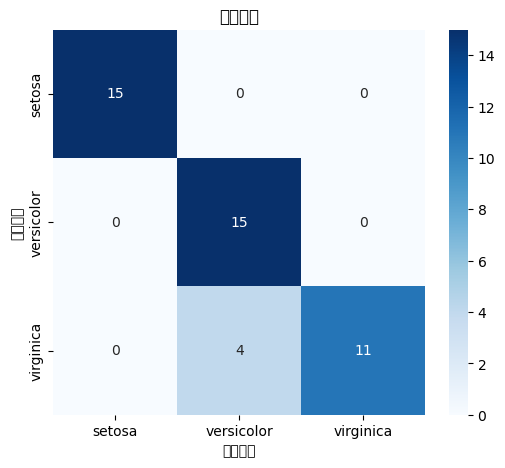

In [20]:
# 画混淆矩阵热力图
plt.figure(figsize = (6, 5))
sns.heatmap(cm, annot = True, fmt = 'd', cmap = 'Blues', xticklabels = iris.target_names, yticklabels = iris.target_names)

plt.xlabel('预测结果')
plt.ylabel('真实结果')
plt.title('混淆矩阵')
plt.show()

# 补丁1  模型之间的对比

In [42]:
# 7. 模型对比：同样的数据，换不同算法，看谁更准
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# 一个字典装模型：名字 → 模型
models = {
    "KNN":           KNeighborsClassifier(),
    "逻辑回归":      LogisticRegression(max_iter=1000, random_state=42),   # max_iter 防止不收敛报警告
    "决策树":        DecisionTreeClassifier(random_state=42),
    "随机森林":      RandomForestClassifier(random_state=42, n_estimators = 3,max_depth = 4)
}

# 循环：每个模型都走一遍"创建→fit→预测→评估"
for name, model in models.items():
    model.fit(X_train_scaled, y_train)                 # 训练
    acc = accuracy_score(y_test, model.predict(X_test_scaled))  # 评估
    print(f"{name:　<6} 准确率: {acc:.2%}")

KNN　　　 准确率: 91.11%
逻辑回归　　 准确率: 91.11%
决策树　　　 准确率: 91.11%
随机森林　　 准确率: 88.89%


# 补丁2  随机森林参数调参

## 1  交叉验证 max_depth

In [44]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score

for d in [1, 2, 3, 4, None]:
    clf = RandomForestClassifier(n_estimators = 100, max_depth = d, random_state = 42)
    scores = cross_val_score(clf, X, y, cv = 5)
    print(f'max_depth = {d}: acc = {scores.mean():.4f} ± {scores.std():.4f}')

max_depth = 1: acc = 0.9467 ± 0.0340
max_depth = 2: acc = 0.9467 ± 0.0340
max_depth = 3: acc = 0.9667 ± 0.0211
max_depth = 4: acc = 0.9667 ± 0.0211
max_depth = None: acc = 0.9667 ± 0.0211


# 补丁4 标准化 + Pipeline 重跑 4模型对比

In [47]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

moodels = {
    '决策树':   DecisionTreeClassifier(max_depth = 3, random_state = 42),
    'KNN':      KNeighborsClassifier(n_neighbors = 5),
    '逻辑回归':  LogisticRegression(max_iter = 1000),
    '随机森林':  RandomForestClassifier(n_estimators = 100,random_state = 42)
}

for name, model in models.items():
    pipe = Pipeline([('scaler',StandardScaler()), ('model',model)])
    scores = cross_val_score(pipe, X, y, cv = 5)
    print(f'{name}: acc = {scores.mean():.4f} ±  {scores.std():.4f}')

KNN: acc = 0.9600 ±  0.0249
逻辑回归: acc = 0.9600 ±  0.0389
决策树: acc = 0.9533 ±  0.0340
随机森林: acc = 0.9733 ±  0.0249


# 补丁5 同 CV、只有"有无标准化"一个变量

In [48]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

moodels = {
    '决策树':   DecisionTreeClassifier(max_depth = 3, random_state = 42),
    'KNN':      KNeighborsClassifier(n_neighbors = 5),
    '逻辑回归':  LogisticRegression(max_iter = 1000),
    '随机森林':  RandomForestClassifier(n_estimators = 100,random_state = 42)
}

for name, model in models.items():
    raw    = cross_val_score(model, X, y, cv=5)
    pipe   = Pipeline([("scaler", StandardScaler()), ("model", model)])
    scaled = cross_val_score(pipe, X, y, cv=5)
    print(f"{name}: 无标准化 {raw.mean():.4f}±{raw.std():.4f} | 标准化 {scaled.mean():.4f}±{scaled.std():.4f}")

KNN: 无标准化 0.9733±0.0249 | 标准化 0.9600±0.0249
逻辑回归: 无标准化 0.9733±0.0249 | 标准化 0.9600±0.0389
决策树: 无标准化 0.9533±0.0340 | 标准化 0.9533±0.0340
随机森林: 无标准化 0.9667±0.0365 | 标准化 0.9733±0.0249


# step9  小结

## 项目总结

In [ ]:
加载数据 → train_test_split 划分 → StandardScaler 预处理 → KNN 训练 → 评估
**这个模板是通用的**：换数据集、换模型（把 KNN 换成 LogisticRegression / RandomForest 都行），
流程完全一样，只是模型那一行改个名字而已。

从附加的模型对比来看决策树和 KNN,逻辑回归的正确率是最高的,为：91.11% ;且在此例中三模型的正确率恰巧相同；最低的是随机森林,为:88.89%

随机森林是"很多棵决策树投票",理论上应该比单棵决策树更稳、更准。但我觉得是因为它在这个例子里反而最低,不是它差,而是 iris 这个数据集太"简单"了:
只有 150 个样本、4 个特征,太小;
随机森林每棵树只能随机看到一部分特征,特征本来就只有 4 个,再被"砍"一刀,每棵树能用的信息更少了;
集成方法的优势(靠多棵树投票来降低波动)在小数据上根本发挥不出来。
所以结论应该是:不是随机森林模型能力不行，而是数据集太小，体现不出他的能力，所以对于小型数据的模型训练不太适合用随机森林
且注意这是随机数据具有很大的随机和偶然性，每次的结果都可能不同，尽量给模型中加上 随机种子 random_state ，一般默认为 42，以便于实验复现
所以，微小的数据差距不必太过介意

## 参数对比说明

In [ ]:
对于随机森林模型:
我分别试了 n_estimators(书的数量) 为 10 和 500，结果都和原来的结果是一样的，都是 88.89%
那么则说明不是 ‘树’ 的数量越多越好，树的数量到一定程度后,准确率就"饱和"了——再加树,只是让预测结果更稳定,准确率不再上升。
最终发现在此例中 n_estimators = 3 时就已经达到饱和，而在 n_estimators = 2 时准确率达到最高 91.11%

在 iris 上,采用 5 折交叉验证后:
单次划分的模型对比结果不可靠(随机森林 从"最差"翻转为"最好",旧表三模型同为 91.11% 是 45 样本测试集的偶然),改用 CV 后全部模型稳定在 95%~97%,彼此无显著差异;
标准化(StandardScaler)对四个模型均无显著影响——本数据集特征同量纲,理论收益无法显现;
max_depth 在 1~None 间对准确率无显著影响(差异在噪声范围内),先前"加深会过拟合"的结论不成立;
结论:iris 数据过于简单,模型选择与预处理对准确率影响有限,需在更复杂数据(CIFAR-10)上进一步验证。